# Credit Card Fraud Detection — Final Portfolio Notebook

An end-to-end machine-learning project for detecting fraudulent credit-card transactions.

### Workflow
1. Load and validate the Kaggle dataset
2. Data-quality checks and duplicate removal
3. Exploratory data analysis
4. Stratified **Train / Validation / Test** split
5. Scale `Time` and `Amount`
6. Apply SMOTE **only to training data**
7. Train Logistic Regression, Random Forest and XGBoost
8. Compare models on the **validation set**
9. Select the model using validation PR-AUC
10. Optimize the classification threshold on validation data
11. Evaluate exactly once on the untouched **test set**
12. Analyze errors and feature importance
13. Explain predictions with SHAP
14. Save a deployment-ready model bundle

> `Class = 0` means legitimate and `Class = 1` means fraud.

## 1. Setup

In [65]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_context("notebook")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Dataset

Expected project structure:

```text
Credit-Card-Fraud-Detection/
├── data/
│   └── creditcard.csv
├── notebooks/
│   └── Credit_Card_Fraud_Detection_Final.ipynb
├── models/
├── images/
├── app/
├── src/
├── README.md
└── requirements.txt
```

In [66]:
DATA_PATH = Path("../data/creditcard.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH.resolve()}\n"
        "Place creditcard.csv inside the project's data/ folder."
    )

df = pd.read_csv(DATA_PATH)

required_columns = {"Time", "Amount", "Class"} | {f"V{i}" for i in range(1, 29)}
missing_required = sorted(required_columns - set(df.columns))

if missing_required:
    raise ValueError(
        "This does not appear to be the expected Kaggle fraud dataset. "
        f"Missing columns: {missing_required}"
    )

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 284,807
Columns: 31


In [67]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

## 3. Data Quality Assessment

In [69]:
print(f"Shape: {df.shape}")
print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Total missing values: {df.isna().sum().sum():,}")

missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

Shape: (284807, 31)
Duplicate rows: 1,081
Total missing values: 0


Series([], dtype: int64)

In [70]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,"284,807.0000","94,813.8596","47,488.1460",0.0000,"54,201.5000","84,692.0000","139,320.5000","172,792.0000"
V1,"284,807.0000",0.0000,1.9587,-56.4075,-0.9204,0.0181,1.3156,2.4549
V2,"284,807.0000",0.0000,1.6513,-72.7157,-0.5985,0.0655,0.8037,22.0577
V3,"284,807.0000",-0.0000,1.5163,-48.3256,-0.8904,0.1798,1.0272,9.3826
V4,"284,807.0000",0.0000,1.4159,-5.6832,-0.8486,-0.0198,0.7433,16.8753
V5,"284,807.0000",0.0000,1.3802,-113.7433,-0.6916,-0.0543,0.6119,34.8017
V6,"284,807.0000",0.0000,1.3323,-26.1605,-0.7683,-0.2742,0.3986,73.3016
V7,"284,807.0000",-0.0000,1.2371,-43.5572,-0.5541,0.0401,0.5704,120.5895
V8,"284,807.0000",0.0000,1.1944,-73.2167,-0.2086,0.0224,0.3273,20.0072
V9,"284,807.0000",-0.0000,1.0986,-13.4341,-0.6431,-0.0514,0.5971,15.5950


### Duplicate handling

Exact duplicate rows can bias training toward repeated observations, so they are removed before splitting.

In [71]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)

print(f"Rows before duplicate removal: {before:,}")
print(f"Rows after duplicate removal:  {after:,}")
print(f"Duplicates removed:            {before - after:,}")

Rows before duplicate removal: 284,807
Rows after duplicate removal:  283,726
Duplicates removed:            1,081


## 4. Exploratory Data Analysis

In [72]:
class_counts = df["Class"].value_counts().sort_index()
class_pct = df["Class"].value_counts(normalize=True).sort_index() * 100

class_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_pct
})
class_summary.index = ["Legitimate (0)", "Fraud (1)"]
class_summary

,Count,Percentage
Legitimate (0),283253,99.8333
Fraud (1),473,0.1667


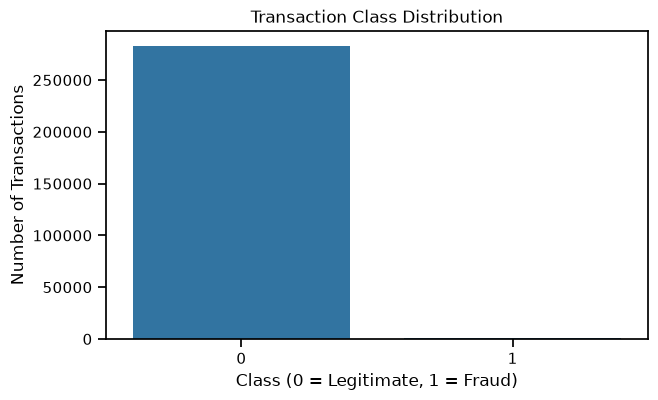

Fraud rate: 0.1667%
Legitimate-to-fraud ratio: 598.8:1


In [73]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Class")
plt.title("Transaction Class Distribution")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

fraud_rate = df["Class"].mean() * 100
imbalance_ratio = (df["Class"] == 0).sum() / (df["Class"] == 1).sum()

print(f"Fraud rate: {fraud_rate:.4f}%")
print(f"Legitimate-to-fraud ratio: {imbalance_ratio:.1f}:1")

### Transaction Amount

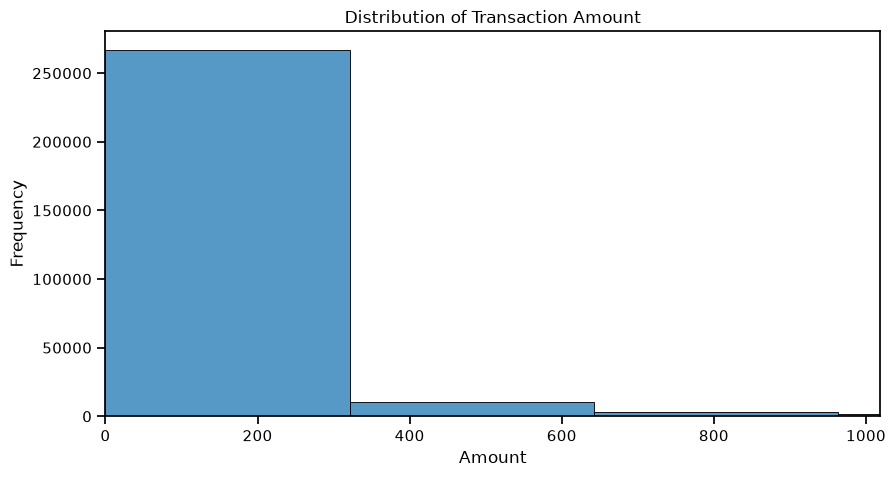

,count,mean,median,min,max
Legitimate,283253,88.4136,22.0000,0.0000,"25,691.1600"
Fraud,473,123.8719,9.8200,0.0000,"2,125.8700"


In [74]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Amount"], bins=80)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.xlim(0, df["Amount"].quantile(0.99))
plt.show()

amount_by_class = df.groupby("Class")["Amount"].agg(
    ["count", "mean", "median", "min", "max"]
)
amount_by_class.index = ["Legitimate", "Fraud"]
amount_by_class

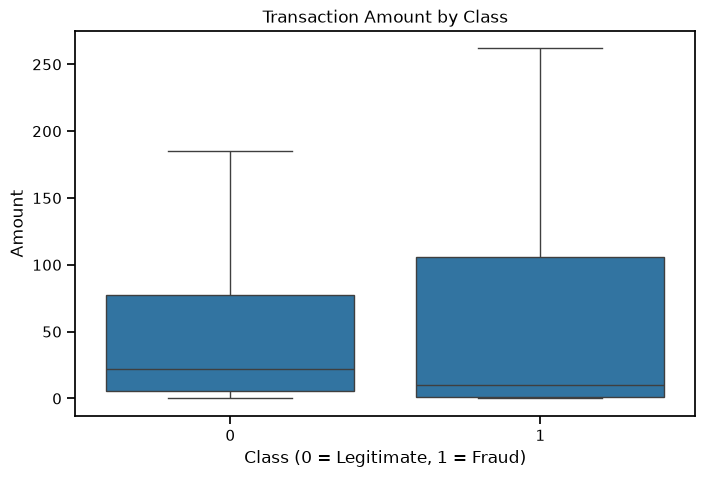

In [75]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Class", y="Amount", showfliers=False)
plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Amount")
plt.show()

### Transaction Time

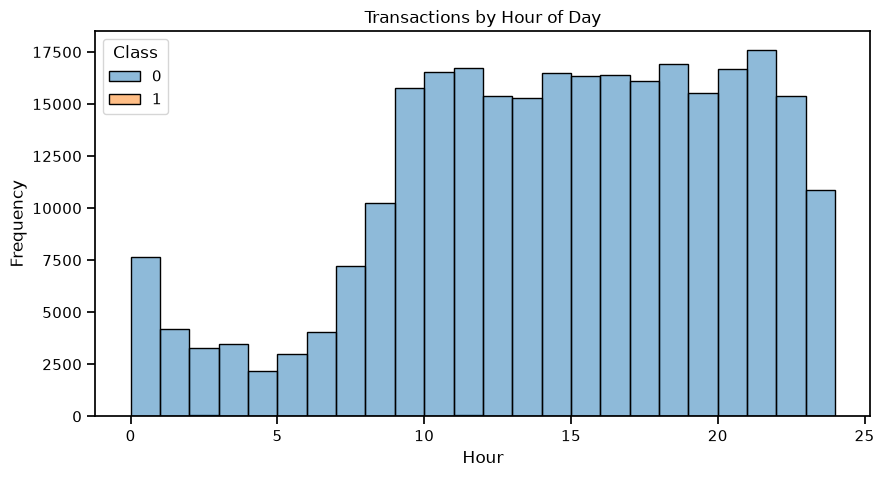

In [76]:
hours = (df["Time"] / 3600) % 24

plt.figure(figsize=(10, 5))
sns.histplot(x=hours, hue=df["Class"].astype(str), bins=24, multiple="layer")
plt.title("Transactions by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Frequency")
plt.show()

### Feature correlations with fraud

`V1`–`V28` are anonymized PCA components, so association with the target should not be interpreted as a real-world causal meaning.

V17   -0.3135
V14   -0.2934
V12   -0.2507
V10   -0.2070
V16   -0.1872
V3    -0.1823
V7    -0.1723
V11    0.1491
V4     0.1293
V18   -0.1053
V1    -0.0945
V9    -0.0940
V5    -0.0878
V2     0.0846
V6    -0.0439
Name: Class, dtype: float64

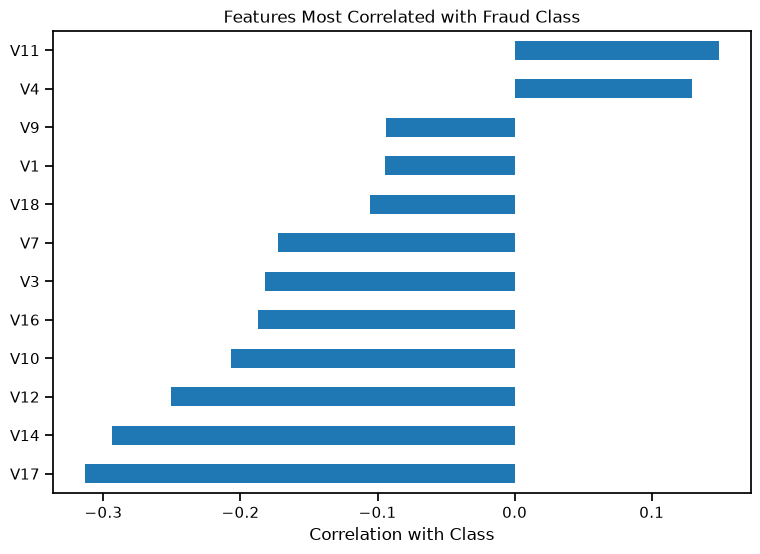

In [77]:
corr_with_class = (
    df.corr(numeric_only=True)["Class"]
      .drop("Class")
      .sort_values(key=abs, ascending=False)
)

display(corr_with_class.head(15))

top_corr = corr_with_class.head(12).sort_values()

plt.figure(figsize=(9, 6))
top_corr.plot(kind="barh")
plt.title("Features Most Correlated with Fraud Class")
plt.xlabel("Correlation with Class")
plt.show()

## 5. Train / Validation / Test Split

We use:

- **70% training data** — model fitting
- **15% validation data** — model selection and threshold optimization
- **15% test data** — final evaluation only

This avoids selecting a model or threshold based on the final test results.

In [78]:
X = df.drop(columns="Class")
y = df["Class"]

# 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

# Split the temporary data equally -> 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Dataset splits")
print("-" * 45)
print(f"Train:      {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:       {X_test.shape}")

print("\nFraud cases")
print("-" * 45)
print(f"Train:      {int(y_train.sum())}")
print(f"Validation: {int(y_val.sum())}")
print(f"Test:       {int(y_test.sum())}")

Dataset splits
---------------------------------------------
Train:      (198608, 30)
Validation: (42559, 30)
Test:       (42559, 30)

Fraud cases
---------------------------------------------
Train:      331
Validation: 71
Test:       71


## 6. Preprocessing

Only `Time` and `Amount` are standardized. The anonymized `V1`–`V28` variables are PCA-derived features.

The preprocessor is fitted **only on training data**.

In [79]:
scale_columns = [col for col in ["Time", "Amount"] if col in X.columns]
passthrough_columns = [col for col in X.columns if col not in scale_columns]

preprocessor = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), scale_columns),
        ("keep", "passthrough", passthrough_columns),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print("Processed shapes")
print(f"Train:      {X_train_processed.shape}")
print(f"Validation: {X_val_processed.shape}")
print(f"Test:       {X_test_processed.shape}")

Processed shapes
Train:      (198608, 30)
Validation: (42559, 30)
Test:       (42559, 30)


## 7. Handle Class Imbalance with SMOTE

SMOTE is applied **only to the training set**. Validation and test sets keep their natural class distribution.

In [80]:
smote = SMOTE(random_state=RANDOM_STATE)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
Class
0    198277
1       331
Name: count, dtype: int64

After SMOTE:
Class
0    198277
1    198277
Name: count, dtype: int64


## 8. Evaluation Helper

In [81]:
validation_results = []

def evaluate_model(name, model, X_eval, y_eval, threshold=0.5, save_result=True):
    probabilities = model.predict_proba(X_eval)[:, 1]
    predictions = (probabilities >= threshold).astype(int)

    metrics = {
        "Model": name,
        "Threshold": float(threshold),
        "Accuracy": accuracy_score(y_eval, predictions),
        "Precision": precision_score(y_eval, predictions, zero_division=0),
        "Recall": recall_score(y_eval, predictions, zero_division=0),
        "F1": f1_score(y_eval, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_eval, probabilities),
        "PR-AUC": average_precision_score(y_eval, probabilities),
    }

    print(f"--- {name} ---")
    for key, value in metrics.items():
        if key != "Model":
            print(f"{key}: {value:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_eval, predictions, digits=4, zero_division=0))

    ConfusionMatrixDisplay.from_predictions(
        y_eval,
        predictions,
        values_format=","
    )
    plt.title(f"{name} — Confusion Matrix")
    plt.show()

    if save_result:
        validation_results.append(metrics)

    return metrics, probabilities, predictions

## 9. Model 1 — Logistic Regression

--- Logistic Regression ---
Threshold: 0.5000
Accuracy: 0.9712
Precision: 0.0492
Recall: 0.8873
F1: 0.0933
ROC-AUC: 0.9735
PR-AUC: 0.6986

Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9714    0.9854     42488
           1     0.0492    0.8873    0.0933        71

    accuracy                         0.9712     42559
   macro avg     0.5245    0.9293    0.5393     42559
weighted avg     0.9982    0.9712    0.9839     42559



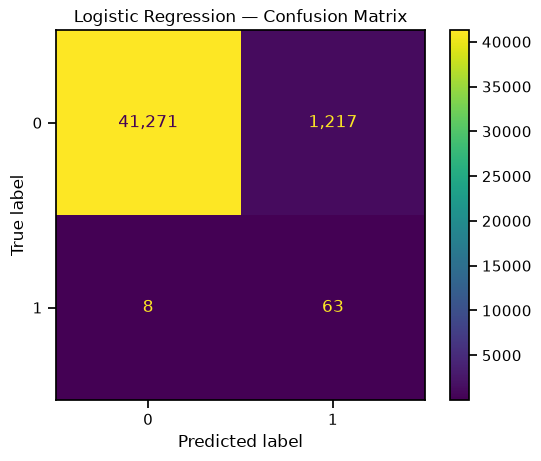

In [82]:
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE
)

logistic_model.fit(X_train_smote, y_train_smote)

log_metrics, log_probs, log_preds = evaluate_model(
    "Logistic Regression",
    logistic_model,
    X_val_processed,
    y_val
)

## 10. Model 2 — Random Forest

--- Random Forest ---
Threshold: 0.5000
Accuracy: 0.9995
Precision: 0.9310
Recall: 0.7606
F1: 0.8372
ROC-AUC: 0.9597
PR-AUC: 0.8409

Classification Report:
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     42488
           1     0.9310    0.7606    0.8372        71

    accuracy                         0.9995     42559
   macro avg     0.9653    0.8802    0.9185     42559
weighted avg     0.9995    0.9995    0.9995     42559



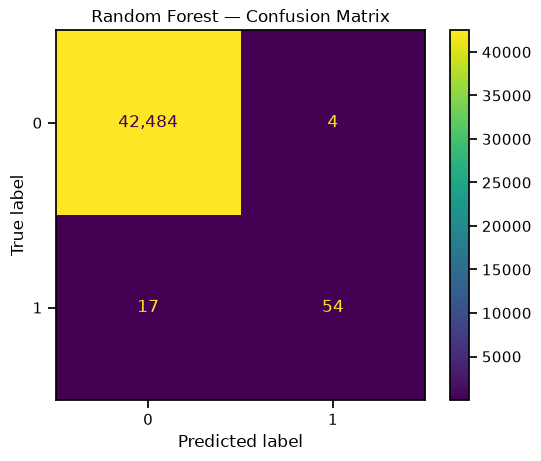

In [83]:
rf_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf_model.fit(X_train_smote, y_train_smote)

rf_metrics, rf_probs, rf_preds = evaluate_model(
    "Random Forest",
    rf_model,
    X_val_processed,
    y_val
)

## 11. Model 3 — XGBoost

--- XGBoost ---
Threshold: 0.5000
Accuracy: 0.9980
Precision: 0.4375
Recall: 0.7887
F1: 0.5628
ROC-AUC: 0.9733
PR-AUC: 0.7980

Classification Report:
              precision    recall  f1-score   support

           0     0.9996    0.9983    0.9990     42488
           1     0.4375    0.7887    0.5628        71

    accuracy                         0.9980     42559
   macro avg     0.7186    0.8935    0.7809     42559
weighted avg     0.9987    0.9980    0.9982     42559



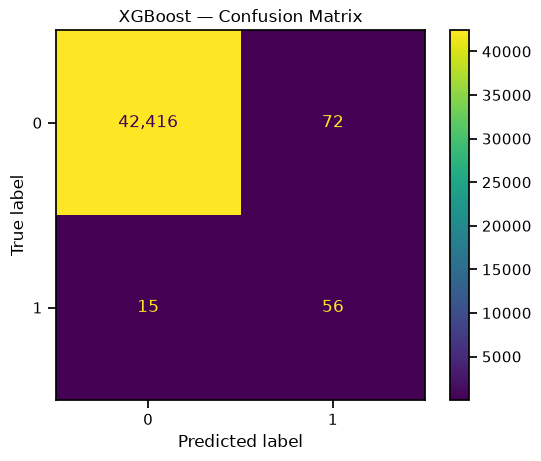

In [84]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(X_train_smote, y_train_smote)

xgb_metrics, xgb_probs, xgb_preds = evaluate_model(
    "XGBoost",
    xgb_model,
    X_val_processed,
    y_val
)

## 12. Validation Model Comparison

For this highly imbalanced problem, PR-AUC, recall, precision and F1 are more informative than accuracy alone.

**Important:** these are validation results, not final test results.

In [85]:
results_df = (
    pd.DataFrame(validation_results)
      .set_index("Model")
      .sort_values("PR-AUC", ascending=False)
)

results_df

,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,,
Random Forest,0.5000,0.9995,0.9310,0.7606,0.8372,0.9597,0.8409
XGBoost,0.5000,0.9980,0.4375,0.7887,0.5628,0.9733,0.7980
Logistic Regression,0.5000,0.9712,0.0492,0.8873,0.0933,0.9735,0.6986


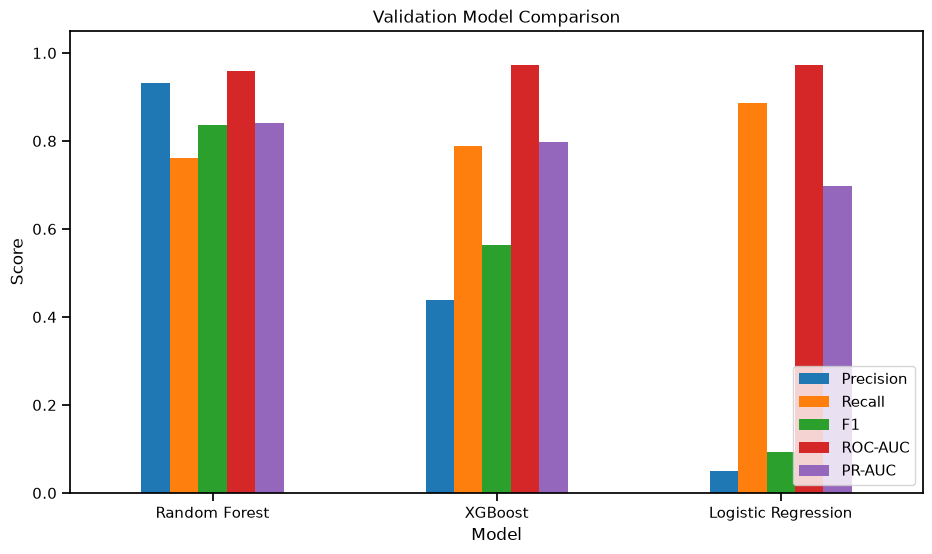

In [86]:
comparison_metrics = ["Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]

results_df[comparison_metrics].plot(
    kind="bar",
    figsize=(11, 6)
)
plt.title("Validation Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

## 13. Validation ROC Curves

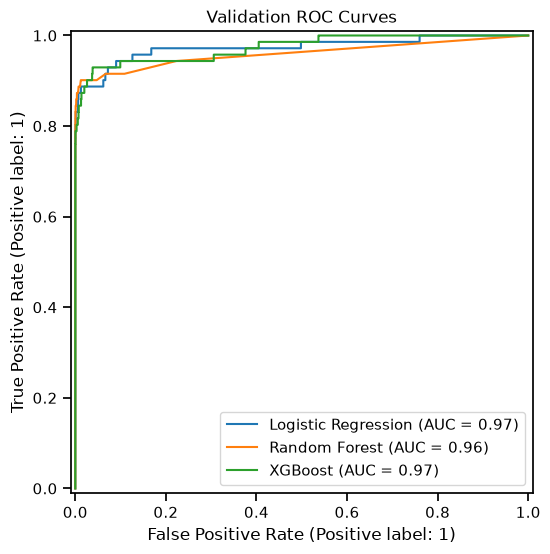

In [87]:
plt.figure(figsize=(8, 6))
ax = plt.gca()

RocCurveDisplay.from_predictions(y_val, log_probs, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_val, rf_probs, name="Random Forest", ax=ax)
RocCurveDisplay.from_predictions(y_val, xgb_probs, name="XGBoost", ax=ax)

plt.title("Validation ROC Curves")
plt.show()

## 14. Validation Precision–Recall Curves

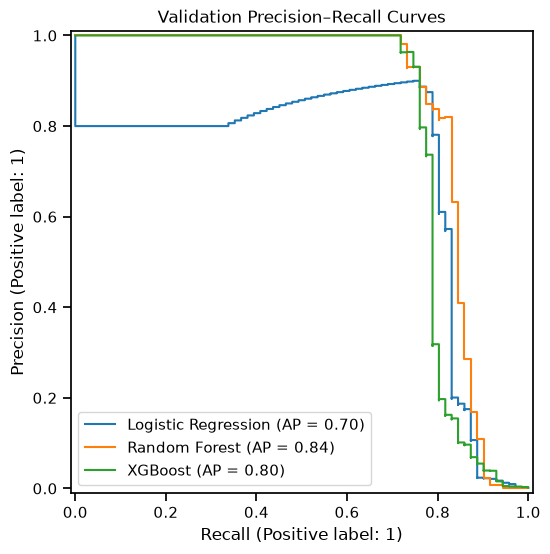

In [88]:
plt.figure(figsize=(8, 6))
ax = plt.gca()

PrecisionRecallDisplay.from_predictions(y_val, log_probs, name="Logistic Regression", ax=ax)
PrecisionRecallDisplay.from_predictions(y_val, rf_probs, name="Random Forest", ax=ax)
PrecisionRecallDisplay.from_predictions(y_val, xgb_probs, name="XGBoost", ax=ax)

plt.title("Validation Precision–Recall Curves")
plt.show()

## 15. Select the Model Using Validation PR-AUC

The test set remains untouched during this decision.

In [89]:
model_lookup = {
    "Logistic Regression": (logistic_model, log_probs),
    "Random Forest": (rf_model, rf_probs),
    "XGBoost": (xgb_model, xgb_probs),
}

best_model_name = results_df["PR-AUC"].idxmax()
best_model, best_val_probs = model_lookup[best_model_name]

print("Selected model:", best_model_name)
print(f"Validation PR-AUC: {results_df.loc[best_model_name, 'PR-AUC']:.4f}")

Selected model: Random Forest
Validation PR-AUC: 0.8409


## 16. Optimize Threshold on Validation Data

The threshold maximizing validation F1 is selected. In a real financial system, the threshold can instead be chosen using explicit costs for false negatives and false positives.

In [90]:
precision, recall, thresholds = precision_recall_curve(y_val, best_val_probs)

f1_scores = 2 * (precision[:-1] * recall[:-1]) / (
    precision[:-1] + recall[:-1] + 1e-12
)

best_index = np.argmax(f1_scores)
best_threshold = float(thresholds[best_index])

print(f"Validation F1-optimal threshold: {best_threshold:.4f}")
print(f"Validation Precision: {precision[best_index]:.4f}")
print(f"Validation Recall:    {recall[best_index]:.4f}")
print(f"Validation F1:        {f1_scores[best_index]:.4f}")

Validation F1-optimal threshold: 0.6800
Validation Precision: 0.9811
Validation Recall:    0.7324
Validation F1:        0.8387


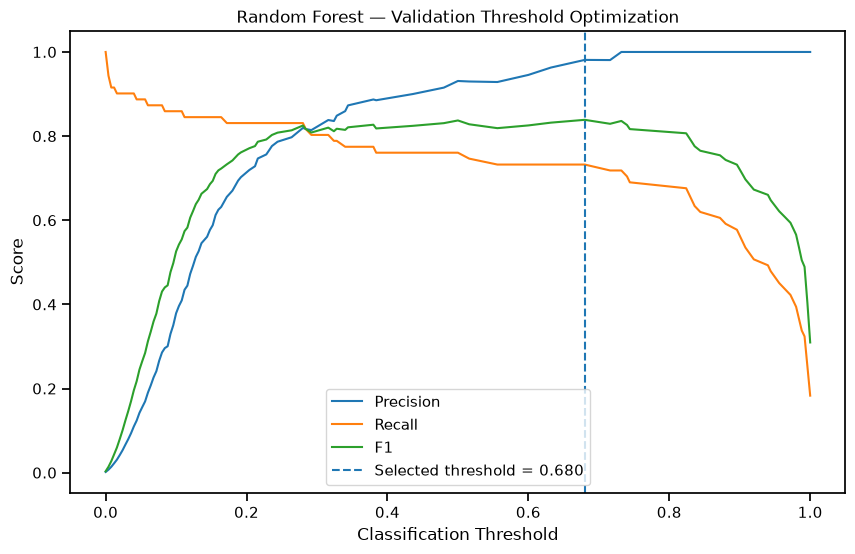

In [91]:
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.plot(thresholds, f1_scores, label="F1")
plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Selected threshold = {best_threshold:.3f}"
)
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title(f"{best_model_name} — Validation Threshold Optimization")
plt.legend()
plt.show()

## 17. Final Evaluation on the Untouched Test Set

This is the most important evaluation section.

The model and threshold were chosen using training/validation data. The test set is now evaluated **once** to estimate generalization performance.

In [92]:
test_probs = best_model.predict_proba(X_test_processed)[:, 1]
test_predictions = (test_probs >= best_threshold).astype(int)

final_test_metrics = {
    "Accuracy": accuracy_score(y_test, test_predictions),
    "Precision": precision_score(y_test, test_predictions, zero_division=0),
    "Recall": recall_score(y_test, test_predictions, zero_division=0),
    "F1": f1_score(y_test, test_predictions, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, test_probs),
    "PR-AUC": average_precision_score(y_test, test_probs),
}

print("FINAL TEST RESULTS")
print("=" * 50)
print(f"Model:     {best_model_name}")
print(f"Threshold: {best_threshold:.4f}")
for metric, value in final_test_metrics.items():
    print(f"{metric:<10}: {value:.4f}")

FINAL TEST RESULTS
Model:     Random Forest
Threshold: 0.6800
Accuracy  : 0.9995
Precision : 0.9455
Recall    : 0.7324
F1        : 0.8254
ROC-AUC   : 0.9781
PR-AUC    : 0.8064


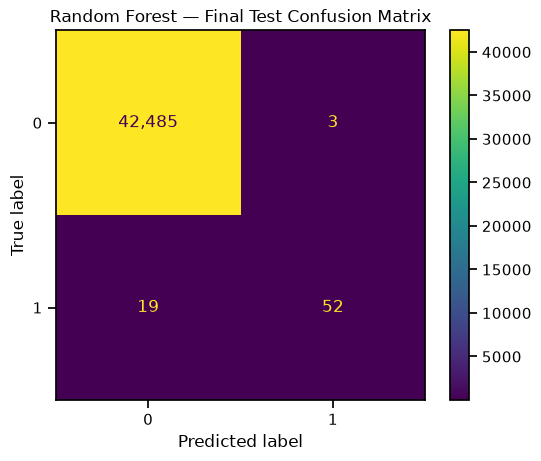

              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9997     42488
           1     0.9455    0.7324    0.8254        71

    accuracy                         0.9995     42559
   macro avg     0.9725    0.8662    0.9126     42559
weighted avg     0.9995    0.9995    0.9995     42559



In [93]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    values_format=","
)
plt.title(f"{best_model_name} — Final Test Confusion Matrix")
plt.show()

print(classification_report(
    y_test,
    test_predictions,
    digits=4,
    zero_division=0
))

## 18. Business-Oriented Error Analysis

In [94]:
cm = confusion_matrix(y_test, test_predictions)
tn, fp, fn, tp = cm.ravel()

error_summary = pd.DataFrame({
    "Metric": [
        "True Negatives",
        "False Positives",
        "False Negatives",
        "True Positives",
        "Fraud Recall",
        "False Positive Rate"
    ],
    "Value": [
        tn,
        fp,
        fn,
        tp,
        tp / (tp + fn) if (tp + fn) else 0,
        fp / (fp + tn) if (fp + tn) else 0
    ]
})

error_summary

,Metric,Value
0,True Negatives,"42,485.0000"
1,False Positives,3.0000
2,False Negatives,19.0000
3,True Positives,52.0000
4,Fraud Recall,0.7324
5,False Positive Rate,0.0001


### Business interpretation

- **False Positive (FP):** a legitimate transaction is flagged as fraud. This may inconvenience a customer and increase investigation costs.
- **False Negative (FN):** a fraudulent transaction is missed. This may cause direct financial loss.
- The optimal operating threshold therefore depends on the organization's relative cost of these errors.

## 19. Feature Importance

,Importance
V14,0.1831
V12,0.1219
V4,0.1142
V17,0.0958
V10,0.0942
V11,0.0712
V3,0.0522
V16,0.0365
V7,0.0313
V2,0.0225


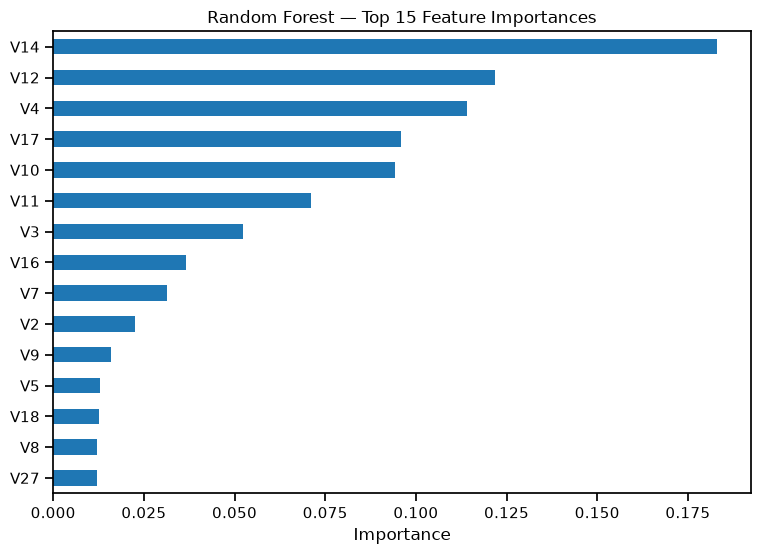

In [95]:
if hasattr(best_model, "feature_importances_"):
    importance = pd.Series(
        best_model.feature_importances_,
        index=feature_names
    ).sort_values(ascending=False)

    display(importance.head(15).to_frame("Importance"))

    plt.figure(figsize=(9, 6))
    importance.head(15).sort_values().plot(kind="barh")
    plt.title(f"{best_model_name} — Top 15 Feature Importances")
    plt.xlabel("Importance")
    plt.show()

elif hasattr(best_model, "coef_"):
    importance = pd.Series(
        np.abs(best_model.coef_[0]),
        index=feature_names
    ).sort_values(ascending=False)

    display(importance.head(15).to_frame("Absolute Coefficient"))

    plt.figure(figsize=(9, 6))
    importance.head(15).sort_values().plot(kind="barh")
    plt.title(f"{best_model_name} — Top 15 Absolute Coefficients")
    plt.xlabel("Absolute Coefficient")
    plt.show()

## 20. SHAP Explainability

SHAP is calculated on a small test sample to keep execution practical on a laptop.

Because `V1`–`V28` are anonymized PCA features, SHAP can show which features influenced a prediction but cannot reveal their original confidential meanings.

In [96]:
import shap

SHAP_SAMPLE_SIZE = min(300, len(X_test_processed))
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(
    len(X_test_processed),
    size=SHAP_SAMPLE_SIZE,
    replace=False
)

X_shap = X_test_processed[sample_idx]
X_shap_df = pd.DataFrame(X_shap, columns=feature_names)

print(f"Explaining {SHAP_SAMPLE_SIZE} test transactions with SHAP.")

Explaining 300 test transactions with SHAP.


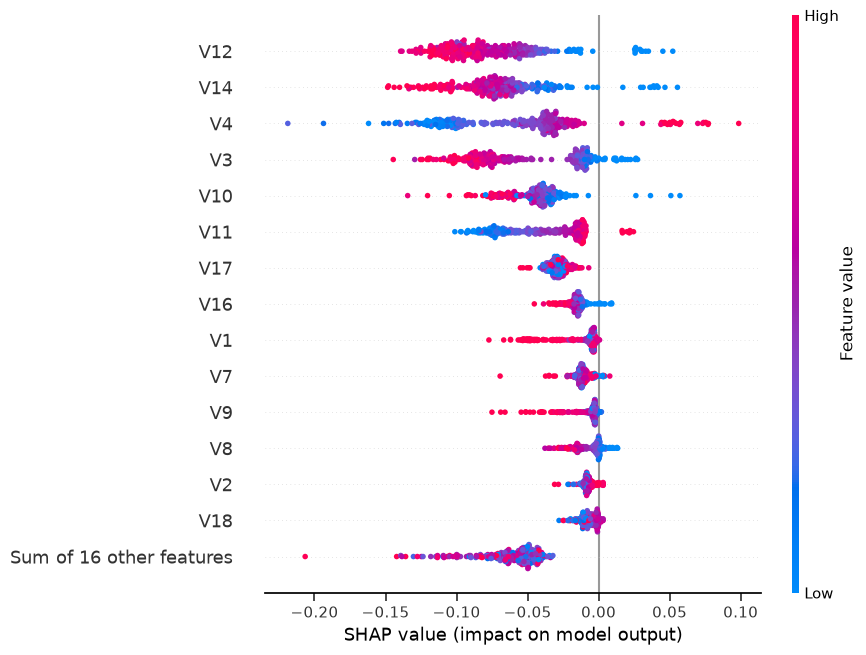

In [97]:
if best_model_name in {"Random Forest", "XGBoost"}:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer(X_shap_df)

    values = shap_values

    # Compatibility handling for SHAP versions that return
    # a separate output dimension for binary classifiers.
    if hasattr(shap_values, "values") and shap_values.values.ndim == 3:
        values = shap.Explanation(
            values=shap_values.values[:, :, 1],
            base_values=shap_values.base_values[:, 1],
            data=shap_values.data,
            feature_names=feature_names
        )

    shap.plots.beeswarm(values, max_display=15)

else:
    background_size = min(100, len(X_train_smote))
    background = shap.sample(
        pd.DataFrame(X_train_smote, columns=feature_names),
        background_size,
        random_state=RANDOM_STATE
    )

    explainer = shap.Explainer(best_model, background)
    shap_values = explainer(X_shap_df)
    shap.plots.beeswarm(shap_values, max_display=15)

## 21. Save the Final Deployment Bundle

The bundle contains:

- fitted preprocessing object
- selected classifier
- validation-selected threshold
- input column order
- processed feature names
- final test metrics

The Streamlit application can load this single file.

In [98]:
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODELS_DIR / "fraud_detection_bundle.joblib"

model_bundle = {
    "preprocessor": preprocessor,
    "model": best_model,
    "model_name": best_model_name,
    "threshold": float(best_threshold),
    "feature_names": list(feature_names),
    "raw_input_columns": list(X.columns),
    "final_test_metrics": final_test_metrics,
}

joblib.dump(model_bundle, MODEL_PATH)

print(f"Saved model bundle to: {MODEL_PATH.resolve()}")

Saved model bundle to: /Users/avinash/Chanchal/ResumeProjects/Credit_Card_Fraud_Detection/Credit-Card-Fraud-Detection/models/fraud_detection_bundle.joblib


## 22. Test the Saved Model

In [99]:
loaded_bundle = joblib.load(MODEL_PATH)

loaded_preprocessor = loaded_bundle["preprocessor"]
loaded_model = loaded_bundle["model"]
loaded_threshold = loaded_bundle["threshold"]

sample_transaction = X_test.iloc[[0]].copy()

sample_processed = loaded_preprocessor.transform(sample_transaction)
fraud_probability = loaded_model.predict_proba(sample_processed)[:, 1][0]
fraud_prediction = int(fraud_probability >= loaded_threshold)

print(f"Model: {loaded_bundle['model_name']}")
print(f"Fraud probability: {fraud_probability:.6f}")
print(f"Threshold: {loaded_threshold:.6f}")
print(f"Prediction: {'FRAUD' if fraud_prediction == 1 else 'LEGITIMATE'}")
print(f"Actual class: {int(y_test.iloc[0])}")

Model: Random Forest
Fraud probability: 0.028000
Threshold: 0.680000
Prediction: LEGITIMATE
Actual class: 1


## 23. Reusable Prediction Function

In [100]:
def predict_fraud(transaction_df, bundle):
    expected_columns = bundle["raw_input_columns"]

    missing_columns = [
        col for col in expected_columns
        if col not in transaction_df.columns
    ]

    if missing_columns:
        raise ValueError(f"Missing columns: {missing_columns}")

    transaction_df = transaction_df[expected_columns]

    processed = bundle["preprocessor"].transform(transaction_df)
    probabilities = bundle["model"].predict_proba(processed)[:, 1]
    predictions = (probabilities >= bundle["threshold"]).astype(int)

    output = transaction_df.copy()
    output["fraud_probability"] = probabilities
    output["fraud_prediction"] = predictions

    return output

In [101]:
prediction_example = predict_fraud(
    X_test.iloc[:5].copy(),
    loaded_bundle
)

prediction_example[[
    "Amount",
    "fraud_probability",
    "fraud_prediction"
]]

,Amount,fraud_probability,fraud_prediction
248322,"1,096.9900",0.0280,0
133635,20.6400,0.0000,0
114060,60.1700,0.0000,0
279467,711.5600,0.0000,0
180293,50.9700,0.0000,0


## 24. Final Project Conclusions

After running all cells, use the values printed under **FINAL TEST RESULTS** as the project's official model metrics.

### Key learning points

- Credit-card fraud detection is a severely imbalanced classification problem.
- Accuracy alone is insufficient for evaluating rare fraud cases.
- Exact duplicates were removed before model training.
- SMOTE was applied only to the training set.
- Logistic Regression provides an interpretable baseline.
- Random Forest and XGBoost capture nonlinear relationships.
- PR-AUC is particularly useful for rare-event classification.
- Model selection and threshold tuning use validation data rather than test data.
- The final test set remains untouched until the final evaluation.
- Threshold selection should ultimately reflect business costs.
- Feature importance and SHAP improve model interpretability.
- Saving preprocessing, model and threshold together simplifies deployment.

### Next step

Build a **Streamlit Fraud Detection Dashboard** using `fraud_detection_bundle.joblib`.